# Transfer Learning con ResNet18 - Oxford-IIIT Pet Dataset

Este notebook implementa **Transfer Learning** usando ResNet18 preentrenado en ImageNet.

## Estrategia:
1. Cargar ResNet18 preentrenado
2. **Congelar todas las capas** (freeze weights)
3. **Reemplazar la última capa** (fully connected) para 37 clases
4. Entrenar solo la última capa

## Dataset:
Oxford-IIIT Pet Dataset con 37 razas de perros y gatos

## 1. Importar librerías

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
import copy
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA disponible: True
GPU: NVIDIA RTX A2000 Laptop GPU


## 2. Configurar dispositivo y rutas

In [54]:
# Configuración del dispositivo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Rutas
data_dir = '../data/oxford-iiit-pet'
images_dir = os.path.join(data_dir, 'images')
annotations_file = os.path.join(data_dir, 'annotations', 'list.txt')

Usando dispositivo: cuda:0


## 3. Dataset personalizado para Oxford Pet

In [55]:
# Celda para reemplazar la clase OxfordPetDataset

class OxfordPetDataset(Dataset):
    """Dataset personalizado para Oxford-IIIT Pet."""
    
    def __init__(self, annotations_file, images_dir, transform=None):
        """
        Args:
            annotations_file: Archivo con anotaciones (list.txt)
            images_dir: Directorio con las imágenes
            transform: Transformaciones a aplicar
        """
        self.images_dir = images_dir
        self.transform = transform
        self.samples = []
        
        # Primero, leer TODAS las clases del archivo y crear mapeo
        breed_to_classid = {}
        classid_to_breed = {}
        
        with open(annotations_file, 'r') as f:
            for line in f:
                if line.startswith('#'):
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    image_name = parts[0]
                    class_id = int(parts[1]) - 1  # 0-indexed
                    
                    # Extraer nombre de la raza
                    breed_name = '_'.join(image_name.split('_')[:-1])
                    
                    if breed_name not in breed_to_classid:
                        breed_to_classid[breed_name] = class_id
                        classid_to_breed[class_id] = breed_name
        
        # Crear lista ordenada de nombres de clases usando los class_id
        self.class_names = [classid_to_breed[i] for i in sorted(classid_to_breed.keys())]
        self.breed_to_idx = {breed: idx for idx, breed in enumerate(self.class_names)}
        
        # Ahora leer las muestras y mapear correctamente
        with open(annotations_file, 'r') as f:
            for line in f:
                if line.startswith('#'):
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    image_name = parts[0]
                    
                    # Construir path
                    image_path = os.path.join(images_dir, f"{image_name}.jpg")
                    
                    if os.path.exists(image_path):
                        # Extraer raza y mapear al índice CORRECTO
                        breed_name = '_'.join(image_name.split('_')[:-1])
                        label = self.breed_to_idx[breed_name]
                        
                        self.samples.append((image_path, label))
        
        print(f"Dataset cargado: {len(self.samples)} imágenes, {len(self.class_names)} clases")
        print(f"Mapeo clase->índice creado correctamente")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        
        try:
            image = Image.open(image_path).convert('RGB')
            
            if self.transform:
                image = self.transform(image)
            
            return image, label
        except Exception as e:
            print(f"Error cargando {image_path}: {e}")
            # Retornar imagen en blanco si hay error
            if self.transform:
                dummy_image = Image.new('RGB', (224, 224), color='white')
                return self.transform(dummy_image), label
            return None, label

## 4. Transformaciones de datos

**IMPORTANTE**: Sin data augmentation, solo transformaciones básicas necesarias para ResNet18.

In [56]:
# Transformaciones básicas (IGUALES para train, val y test)
# SIN data augmentation
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Media de ImageNet
                        std=[0.229, 0.224, 0.225])     # Std de ImageNet
])

print("✓ Transformaciones configuradas (SIN data augmentation)")
print("  - Resize a 256x256")
print("  - Center crop a 224x224")
print("  - Normalización con estadísticas de ImageNet")

✓ Transformaciones configuradas (SIN data augmentation)
  - Resize a 256x256
  - Center crop a 224x224
  - Normalización con estadísticas de ImageNet


## 5. Cargar dataset y dividir en train/val/test con balance de clases

División estratificada: 60% train, 20% val, 20% test

In [57]:
from torch.utils.data import Subset
from collections import defaultdict
import random

# Crear dataset completo con transformaciones
full_dataset = OxfordPetDataset(annotations_file, images_dir, transform=data_transforms)

# Agrupar índices por clase para hacer división estratificada
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset.samples):
    class_indices[label].append(idx)

# Verificar balance inicial
print("\n=== BALANCE DE CLASES ORIGINAL ===")
for class_id in sorted(class_indices.keys()):
    print(f"{full_dataset.class_names[class_id]:25s}: {len(class_indices[class_id]):3d} imágenes")

# División estratificada: 60% train, 20% val, 20% test
train_indices = []
val_indices = []
test_indices = []

random.seed(42)  # Para reproducibilidad

for class_id, indices in class_indices.items():
    # Mezclar índices de esta clase
    random.shuffle(indices)
    
    n_samples = len(indices)
    n_train = int(0.6 * n_samples)
    n_val = int(0.2 * n_samples)
    # n_test es el resto
    
    train_indices.extend(indices[:n_train])
    val_indices.extend(indices[n_train:n_train + n_val])
    test_indices.extend(indices[n_train + n_val:])

# Mezclar los índices finales
random.shuffle(train_indices)
random.shuffle(val_indices)
random.shuffle(test_indices)

# Crear subsets
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

print(f"\n{'='*60}")
print("DIVISIÓN DEL DATASET (ESTRATIFICADA):")
print(f"{'='*60}")
print(f"  Entrenamiento: {len(train_dataset):5d} imágenes ({100*len(train_dataset)/len(full_dataset):.1f}%)")
print(f"  Validación:    {len(val_dataset):5d} imágenes ({100*len(val_dataset)/len(full_dataset):.1f}%)")
print(f"  Test:          {len(test_dataset):5d} imágenes ({100*len(test_dataset)/len(full_dataset):.1f}%)")
print(f"  Total:         {len(full_dataset):5d} imágenes")
print(f"  Total clases:  {len(full_dataset.class_names)}")

# Verificar balance en cada split
def count_classes_in_subset(dataset, indices):
    class_count = defaultdict(int)
    for idx in indices:
        _, label = dataset.samples[idx]
        class_count[label] += 1
    return class_count

train_class_count = count_classes_in_subset(full_dataset, train_indices)
val_class_count = count_classes_in_subset(full_dataset, val_indices)
test_class_count = count_classes_in_subset(full_dataset, test_indices)

print(f"\n{'='*60}")
print("VERIFICACIÓN DE BALANCE POR CLASE:")
print(f"{'='*60}")
print(f"{'Clase':25s} {'Train':>7s} {'Val':>7s} {'Test':>7s} {'Total':>7s}")
print("-" * 60)
for class_id in sorted(class_indices.keys()):
    class_name = full_dataset.class_names[class_id]
    print(f"{class_name:25s} {train_class_count[class_id]:7d} {val_class_count[class_id]:7d} "
          f"{test_class_count[class_id]:7d} {len(class_indices[class_id]):7d}")

Dataset cargado: 7349 imágenes, 37 clases
Mapeo clase->índice creado correctamente

=== BALANCE DE CLASES ORIGINAL ===
Abyssinian               : 198 imágenes
american_bulldog         : 200 imágenes
american_pit_bull_terrier: 200 imágenes
basset_hound             : 200 imágenes
beagle                   : 200 imágenes
Bengal                   : 200 imágenes
Birman                   : 200 imágenes
Bombay                   : 184 imágenes
boxer                    : 199 imágenes
British_Shorthair        : 200 imágenes
chihuahua                : 200 imágenes
Egyptian_Mau             : 190 imágenes
english_cocker_spaniel   : 196 imágenes
english_setter           : 200 imágenes
german_shorthaired       : 200 imágenes
great_pyrenees           : 200 imágenes
havanese                 : 200 imágenes
japanese_chin            : 200 imágenes
keeshond                 : 199 imágenes
leonberger               : 200 imágenes
Maine_Coon               : 200 imágenes
miniature_pinscher       : 200 imágenes
n

## 6. Crear DataLoaders para train, val y test

In [58]:
# Hiperparámetros
batch_size = 32
num_workers = 0  # Ajustar según tu CPU

# DataLoaders
train_loader = DataLoader(train_dataset, 
                         batch_size=batch_size,
                         shuffle=True,  # Solo shuffle en train
                         num_workers=num_workers,
                         pin_memory=True if torch.cuda.is_available() else False)

val_loader = DataLoader(val_dataset,
                       batch_size=batch_size,
                       shuffle=False,  # No shuffle en val/test
                       num_workers=num_workers,
                       pin_memory=True if torch.cuda.is_available() else False)

test_loader = DataLoader(test_dataset,
                        batch_size=batch_size,
                        shuffle=False,  # No shuffle en val/test
                        num_workers=num_workers,
                        pin_memory=True if torch.cuda.is_available() else False)

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}

print(f"{'='*60}")
print("DATALOADERS CREADOS:")
print(f"{'='*60}")
print(f"  Train batches: {len(train_loader):4d} (shuffle=True)")
print(f"  Val batches:   {len(val_loader):4d} (shuffle=False)")
print(f"  Test batches:  {len(test_loader):4d} (shuffle=False)")
print(f"  Batch size:    {batch_size}")

DATALOADERS CREADOS:
  Train batches:  138 (shuffle=True)
  Val batches:     46 (shuffle=False)
  Test batches:    47 (shuffle=False)
  Batch size:    32


## 7. Visualizar algunas imágenes del dataset

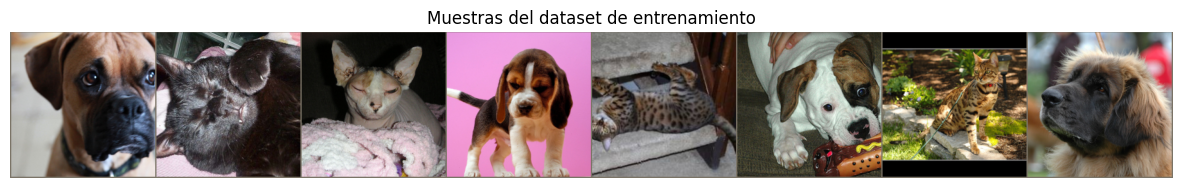

In [59]:
def imshow(inp, title=None):
    """Mostrar imagen desde tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Desnormalizar
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

# Obtener un batch de entrenamiento
inputs, classes = next(iter(train_loader))

# Crear grid de imágenes
out = torchvision.utils.make_grid(inputs[:8])

plt.figure(figsize=(15, 5))
imshow(out, title='Muestras del dataset de entrenamiento')
plt.show()

## 8. Cargar ResNet18 preentrenado y modificar la última capa

### Estrategia de Transfer Learning:
1. Cargar ResNet18 con pesos de ImageNet
2. **Congelar todas las capas** (requiere_grad = False)
3. **Reemplazar la última capa FC** para 37 clases
4. Solo entrenar la última capa

In [60]:
# Cargar ResNet18 preentrenado
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

print("Modelo ResNet18 cargado con pesos de ImageNet")
print(f"\nArquitectura original de la última capa:")
print(model.fc)

Modelo ResNet18 cargado con pesos de ImageNet

Arquitectura original de la última capa:
Linear(in_features=512, out_features=1000, bias=True)


In [61]:
# PASO CLAVE: Congelar todas las capas del modelo
print("\n=== CONGELANDO CAPAS ===")
for param in model.parameters():
    param.requires_grad = False

print("✓ Todas las capas congeladas (requires_grad = False)")

# Verificar que las capas estén congeladas
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"  Parámetros congelados: {frozen_params:,}")


=== CONGELANDO CAPAS ===
✓ Todas las capas congeladas (requires_grad = False)
  Parámetros congelados: 11,689,512


In [62]:
# Reemplazar la última capa (fully connected) para 37 clases
num_classes = 37
num_ftrs = model.fc.in_features  # 512 features de entrada para ResNet18

# Nueva capa FC con inicialización
model.fc = nn.Linear(num_ftrs, num_classes)

print(f"\n=== NUEVA CAPA FINAL ===")
print(f"Nueva capa FC: {num_ftrs} -> {num_classes}")
print(model.fc)

# Mover modelo al dispositivo
model = model.to(device)

# Verificar parámetros entrenables
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"\n=== RESUMEN DE PARÁMETROS ===")
print(f"Total de parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Parámetros congelados: {total_params - trainable_params:,}")
print(f"Porcentaje entrenable: {100 * trainable_params / total_params:.2f}%")


=== NUEVA CAPA FINAL ===
Nueva capa FC: 512 -> 37
Linear(in_features=512, out_features=37, bias=True)

=== RESUMEN DE PARÁMETROS ===
Total de parámetros: 11,195,493
Parámetros entrenables: 18,981
Parámetros congelados: 11,176,512
Porcentaje entrenable: 0.17%


## 9. Configurar función de pérdida y optimizador

Solo optimizamos los parámetros de la última capa.

In [63]:
# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Optimizador - SOLO optimiza los parámetros entrenables (última capa)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=0.001)

# Learning rate scheduler (opcional)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("Configuración:")
print(f"  Función de pérdida: CrossEntropyLoss")
print(f"  Optimizador: Adam (lr=0.001)")
print(f"  Scheduler: StepLR (step=7, gamma=0.1)")
print(f"  Parámetros a optimizar: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Configuración:
  Función de pérdida: CrossEntropyLoss
  Optimizador: Adam (lr=0.001)
  Scheduler: StepLR (step=7, gamma=0.1)
  Parámetros a optimizar: 18,981


## 10. Función de entrenamiento

In [64]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    """
    Entrenar el modelo con transfer learning.
    
    Args:
        model: Modelo a entrenar
        criterion: Función de pérdida
        optimizer: Optimizador
        scheduler: Learning rate scheduler
        num_epochs: Número de épocas
    
    Returns:
        model: Mejor modelo entrenado
        history: Historial de entrenamiento
    """
    since = time.time()
    
    # Historial
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'\nÉpoca {epoch+1}/{num_epochs}')
        print('-' * 60)
        
        # Cada época tiene fase de entrenamiento y validación
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Modo entrenamiento
            else:
                model.eval()   # Modo evaluación
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterar sobre los datos
            pbar = tqdm(dataloaders[phase], desc=f'{phase.capitalize()}')
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero gradients
                optimizer.zero_grad()
                
                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward + optimize solo en entrenamiento
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Estadísticas
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                # Actualizar barra de progreso
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            
            if phase == 'train':
                scheduler.step()
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            # Guardar en historial
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
            
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Guardar mejor modelo
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'✓ Mejor modelo actualizado (acc: {best_acc:.4f})')
    
    time_elapsed = time.time() - since
    print(f'\n{"="*60}')
    print(f'Entrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor accuracy de validación: {best_acc:.4f}')
    
    # Cargar mejores pesos
    model.load_state_dict(best_model_wts)
    return model, history

## 11. Entrenar el modelo

In [65]:
# Entrenar el modelo
num_epochs = 50

print("Iniciando entrenamiento...")
print(f"Épocas: {num_epochs}")
print(f"\nRECORDAR: Solo se entrena la última capa (FC)")
print(f"Todas las demás capas están congeladas\n")

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)

Iniciando entrenamiento...
Épocas: 50

RECORDAR: Solo se entrena la última capa (FC)
Todas las demás capas están congeladas


Época 1/50
------------------------------------------------------------


Train: 100%|██████████| 138/138 [00:39<00:00,  3.46it/s, loss=0.9124]


Train Loss: 1.6805 Acc: 0.6397


Val: 100%|██████████| 46/46 [00:14<00:00,  3.28it/s, loss=0.6296]


Val Loss: 0.7347 Acc: 0.8504
✓ Mejor modelo actualizado (acc: 0.8504)

Época 2/50
------------------------------------------------------------


...

Val Loss: 0.3035 Acc: 0.9098

Época 50/50
------------------------------------------------------------


Train: 100%|██████████| 138/138 [00:46<00:00,  2.99it/s, loss=0.0846]


Train Loss: 0.1749 Acc: 0.9644


Val: 100%|██████████| 46/46 [00:13<00:00,  3.32it/s, loss=0.0887]

Val Loss: 0.3047 Acc: 0.9112

Entrenamiento completado en 53m 38s
Mejor accuracy de validación: 0.9133


## 12. Visualizar resultados del entrenamiento

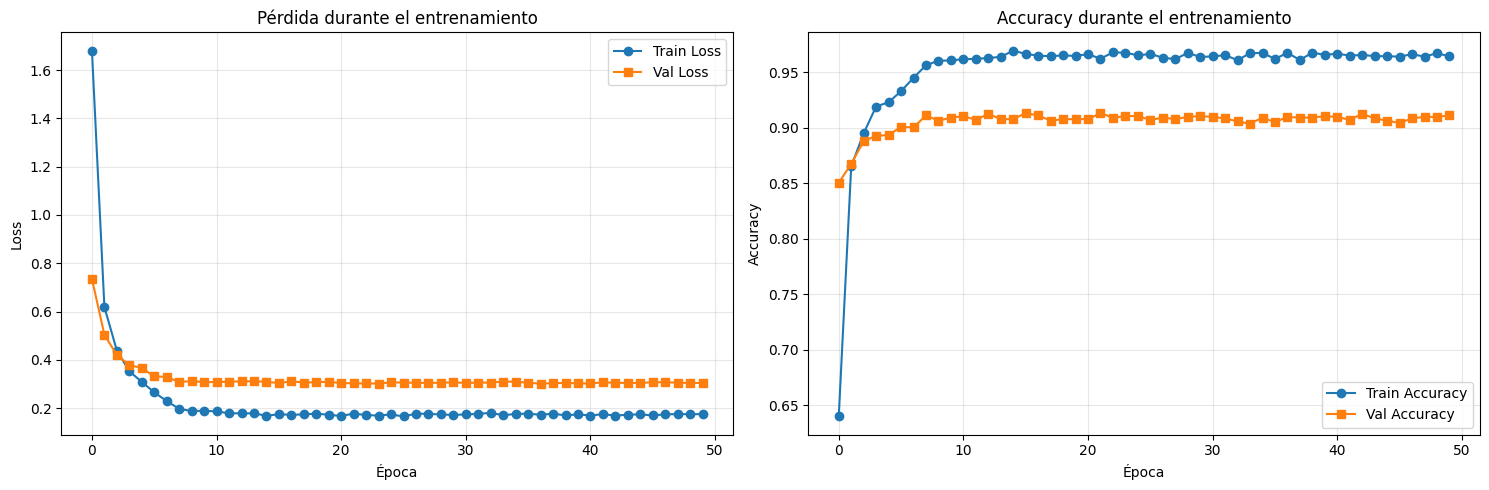


RESULTADOS FINALES:
Última Train Loss: 0.1749
Última Train Acc: 0.9644
Última Val Loss: 0.3047
Última Val Acc: 0.9112

Mejor Val Acc: 0.9133


In [74]:
# Graficar pérdida y accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pérdida
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy durante el entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Imprimir mejores resultados
print(f"\n{'='*60}")
print("RESULTADOS FINALES:")
print(f"{'='*60}")
print(f"Última Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Última Train Acc: {history['train_acc'][-1]:.4f}")
print(f"Última Val Loss: {history['val_loss'][-1]:.4f}")
print(f"Última Val Acc: {history['val_acc'][-1]:.4f}")
print(f"\nMejor Val Acc: {max(history['val_acc']):.4f}")

## 13. Guardar el modelo entrenado

In [75]:
# Guardar el modelo
model_save_path = '../models/resnet18_transfer_learning_oxford.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'num_classes': num_classes,
    'class_names': full_dataset.class_names
}, model_save_path)

print(f"Modelo guardado en: {model_save_path}")

Modelo guardado en: ../models/resnet18_transfer_learning_oxford.pth


## 14. Evaluación FINAL en conjunto de TEST

**IMPORTANTE**: Evaluación sobre el conjunto de test que NO se usó durante el entrenamiento.

In [76]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

def evaluate_model(model, dataloader):
    """Evaluar modelo y obtener predicciones completas."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Evaluando'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)

print("\n" + "="*60)
print("EVALUACIÓN FINAL EN CONJUNTO DE TEST")
print("="*60)
print("Este conjunto NO se usó durante el entrenamiento\n")

# Evaluar en TEST (no en validación)
y_true, y_pred = evaluate_model(model, test_loader)

# Calcular métricas
test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"{'='*60}")
print("MÉTRICAS EN TEST:")
print(f"{'='*60}")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

# Reporte de clasificación
print("\n" + "="*60)
print("REPORTE DETALLADO - CONJUNTO DE TEST")
print("="*60)
print(classification_report(y_true, y_pred, 
                          target_names=full_dataset.class_names,
                          zero_division=0))


EVALUACIÓN FINAL EN CONJUNTO DE TEST
Este conjunto NO se usó durante el entrenamiento



Evaluando: 100%|██████████| 47/47 [00:11<00:00,  3.99it/s]

MÉTRICAS EN TEST:
  Accuracy:  0.9000
  Precision: 0.9024
  Recall:    0.9000
  F1-Score:  0.8994

REPORTE DETALLADO - CONJUNTO DE TEST
                            precision    recall  f1-score   support

                Abyssinian       1.00      0.78      0.88        41
          american_bulldog       0.77      0.82      0.80        40
 american_pit_bull_terrier       0.74      0.70      0.72        40
              basset_hound       0.97      0.93      0.95        40
                    beagle       0.85      0.88      0.86        40
                    Bengal       0.85      0.88      0.86        40
                    Birman       0.71      0.85      0.77        40
                    Bombay       0.95      0.97      0.96        38
                     boxer       0.88      0.90      0.89        41
         British_Shorthair       0.89      0.85      0.87        40
                 chihuahua       0.94      0.82      0.88        40
              Egyptian_Mau       0.84      0.95

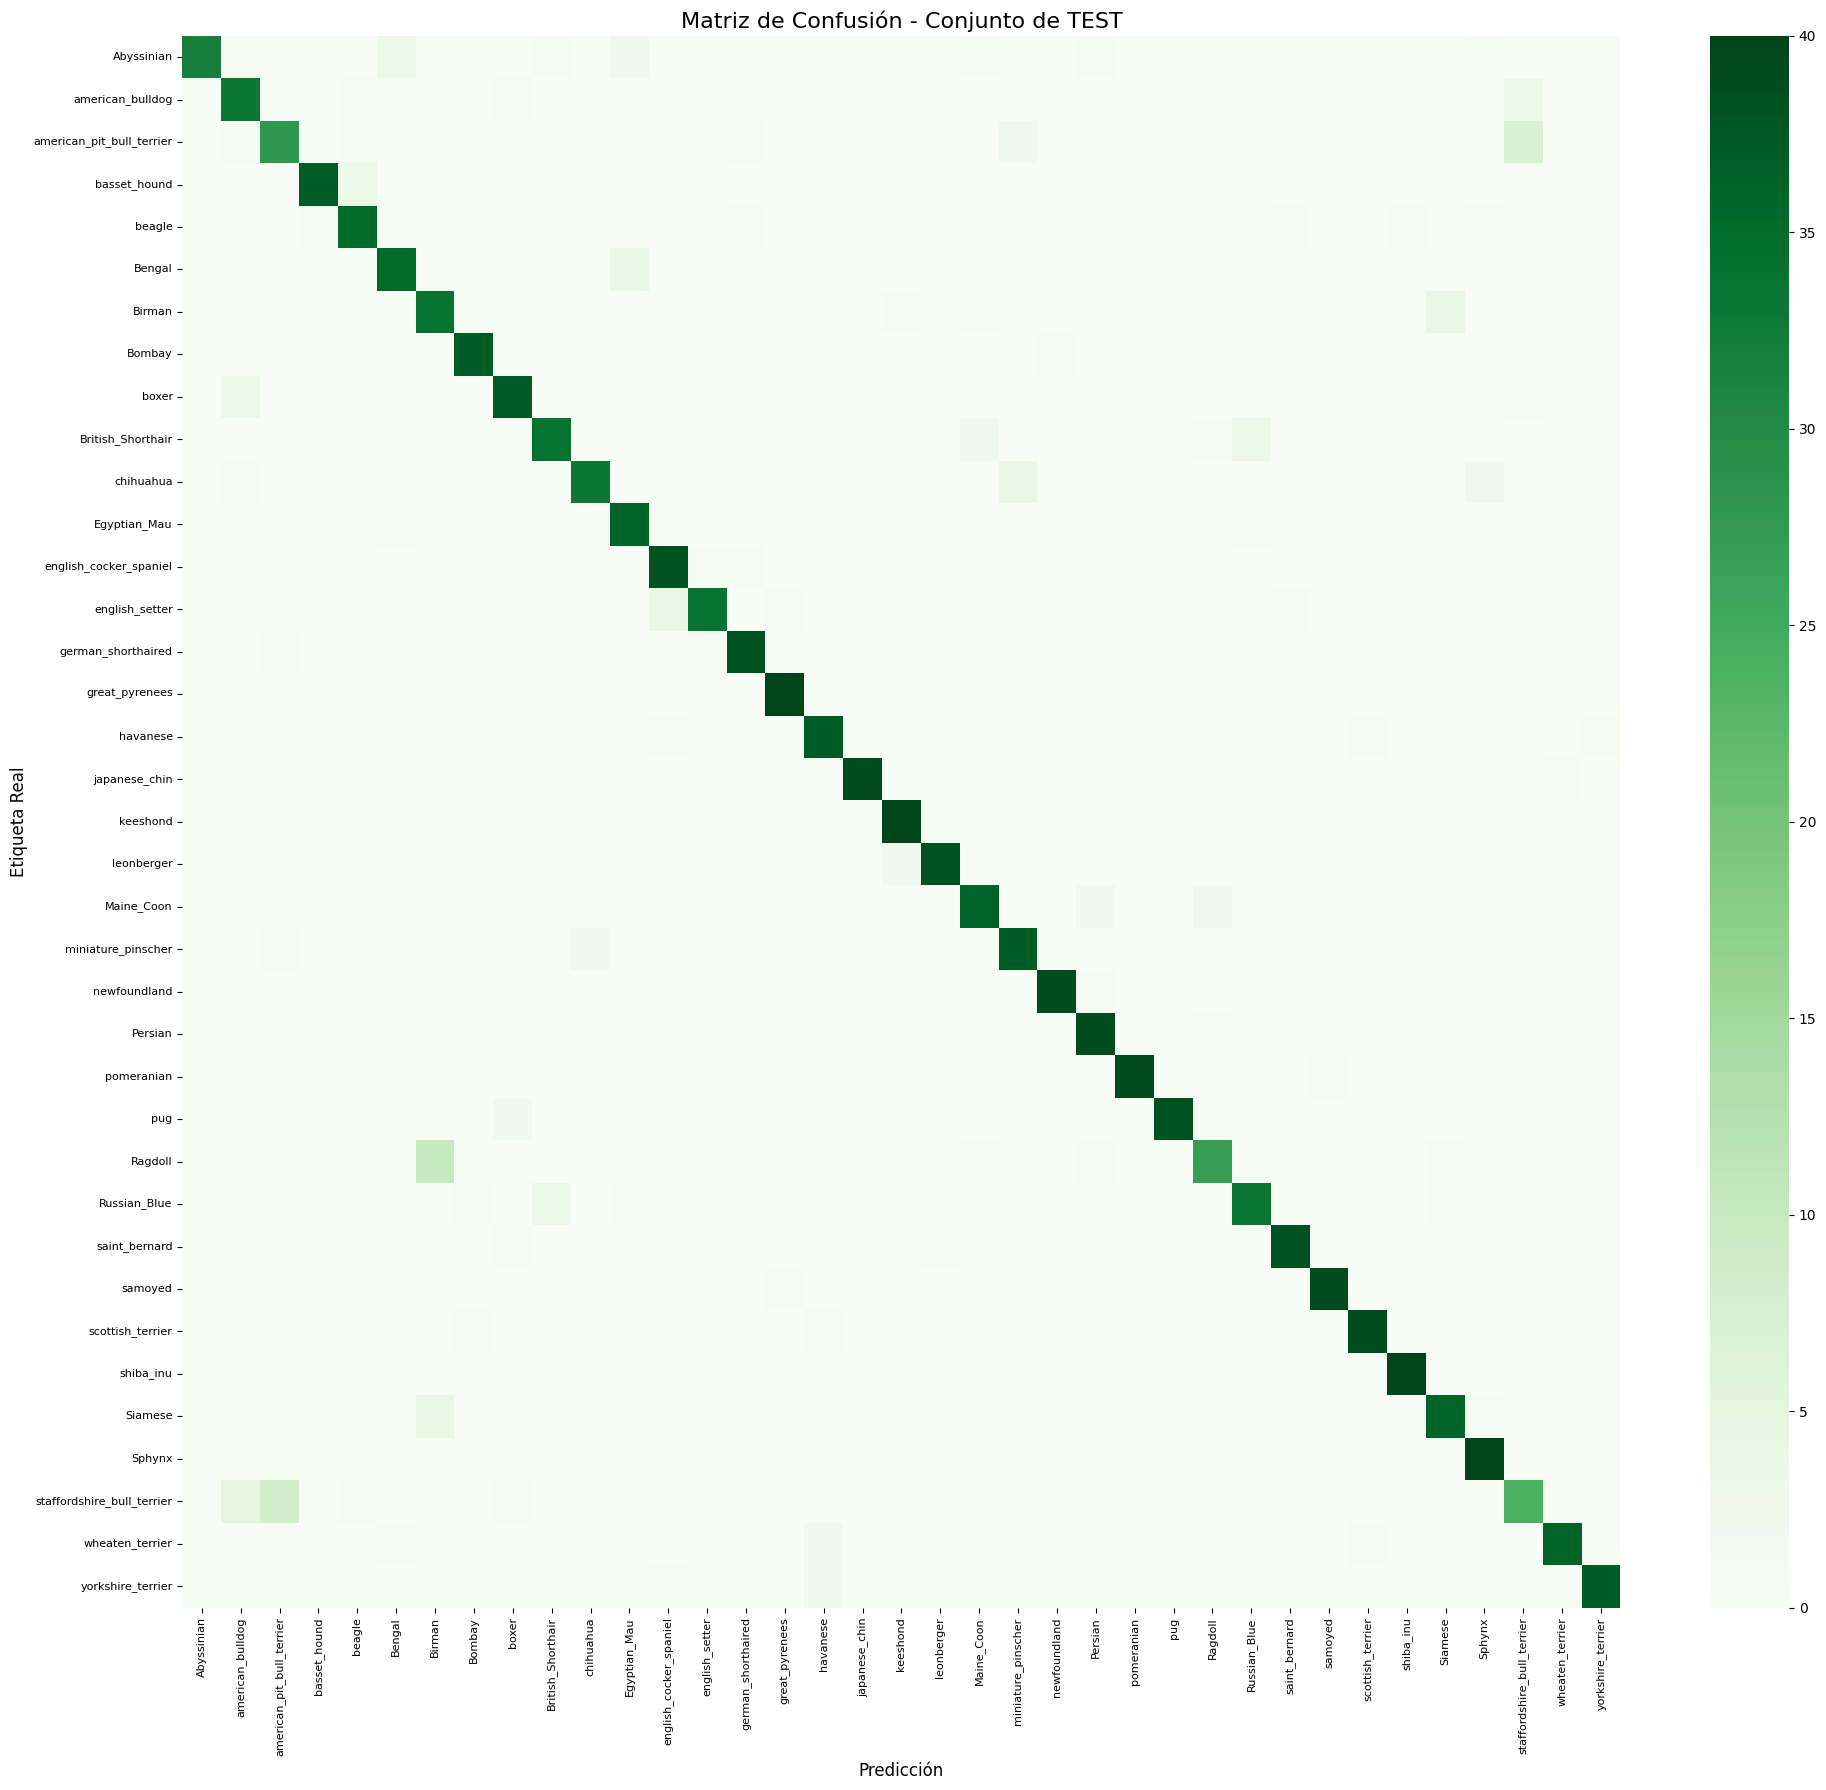


ACCURACY POR CLASE EN TEST:
Abyssinian               : 0.7805 (41 muestras)
american_bulldog         : 0.8250 (40 muestras)
american_pit_bull_terrier: 0.7000 (40 muestras)
basset_hound             : 0.9250 (40 muestras)
beagle                   : 0.8750 (40 muestras)
Bengal                   : 0.8750 (40 muestras)
Birman                   : 0.8500 (40 muestras)
Bombay                   : 0.9737 (38 muestras)
boxer                    : 0.9024 (41 muestras)
British_Shorthair        : 0.8500 (40 muestras)
chihuahua                : 0.8250 (40 muestras)
Egyptian_Mau             : 0.9474 (38 muestras)
english_cocker_spaniel   : 0.9500 (40 muestras)
english_setter           : 0.8500 (40 muestras)
german_shorthaired       : 0.9500 (40 muestras)
great_pyrenees           : 1.0000 (40 muestras)
havanese                 : 0.9250 (40 muestras)
japanese_chin            : 0.9750 (40 muestras)
keeshond                 : 0.9756 (41 muestras)
leonberger               : 0.9500 (40 muestras)
Maine_Coon 

In [78]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Greens', 
            xticklabels=full_dataset.class_names,
            yticklabels=full_dataset.class_names)
plt.title('Matriz de Confusión - Conjunto de TEST', fontsize=16)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Accuracy por clase en TEST
class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\n" + "="*60)
print("ACCURACY POR CLASE EN TEST:")
print("="*60)
for i, acc in enumerate(class_accuracy):
    if not np.isnan(acc):
        count = cm.sum(axis=1)[i]
        print(f"{full_dataset.class_names[i]:25s}: {acc:.4f} ({int(count)} muestras)")

# Visualizar predicciones del test
print("\n" + "="*60)
print("VISUALIZACIÓN DE PREDICCIONES EN TEST")
print("="*60)

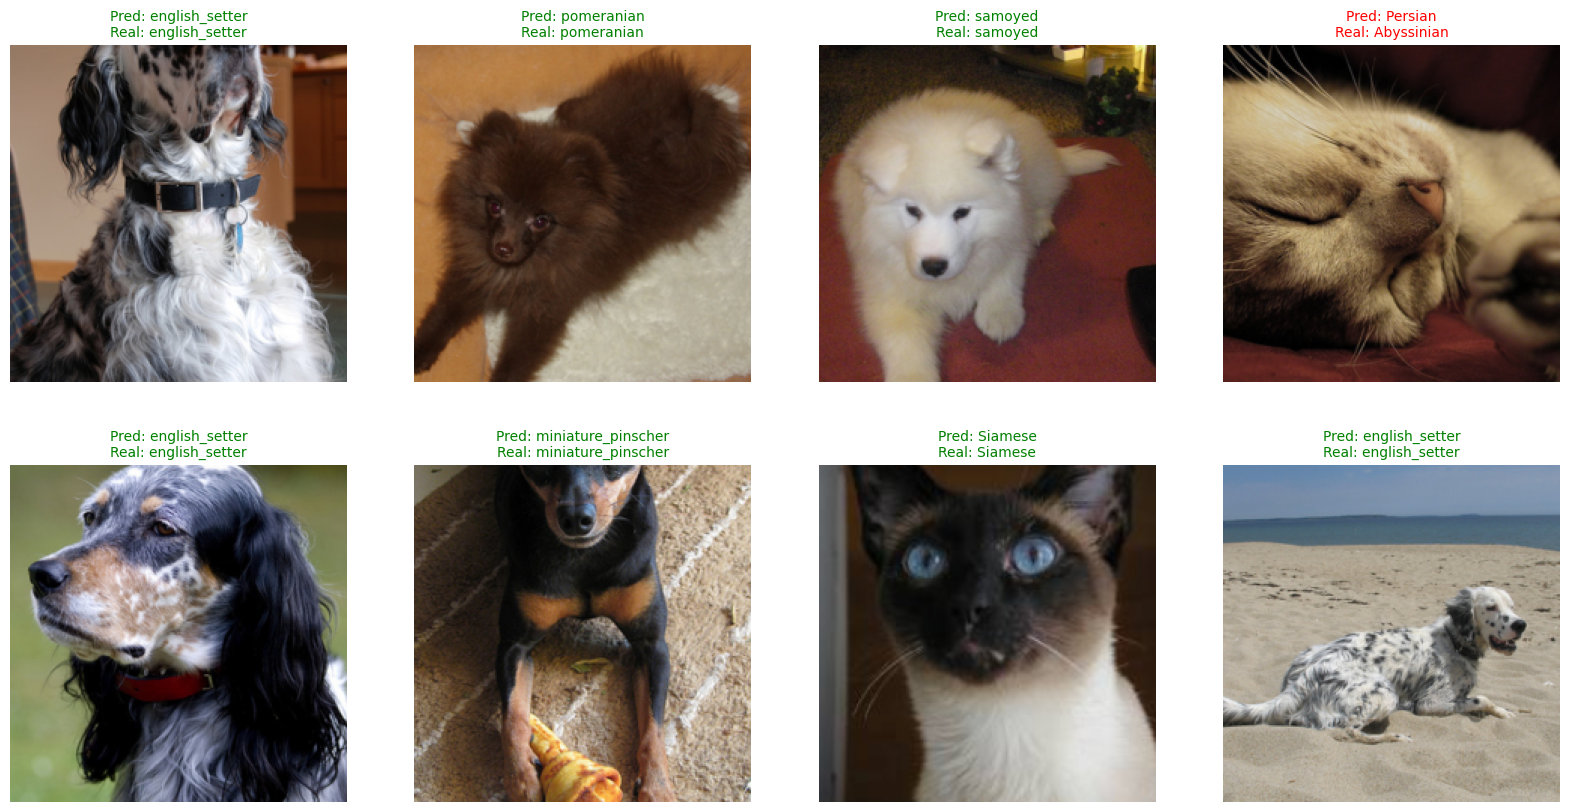

In [82]:
visualize_predictions(model, test_loader, full_dataset.class_names, num_images=8)